# Introducción

Durante esta actividad se busca hacer una comparación de métodos para obtener la similitud entre códigos de pyhton. Para ello se utilizan cuatro métodos. Suffix Array con texto plano, Suffix Array con texto preprocesado, difflib con texto plano y difflib con texto preprocesado.

Para el texto preprocesado se utiliza la libreria tokenizer de python.

El dataset consta de 20 codigos de los cuales los códigos desde el 1 al 12. 16, 18 y  19 igualmente son clones. 

Se utilizará la métrica sugerida:

Similitud = suma de longitudes de subcadenas comunes / longitud de programa más corto


# Configuración Global

## Importación de librerías

tokenize: Biblioteca estándar de Python para análisis léxico de código fuente de Python.

difflib: Biblioteca estándar de Python para comparación de secuencias y detección de diferencias.

matplotlib: Biblioteca para graficar y generar mapa de calor.

numpy: Biblioteca para manejo de arreglos para graficar con matplotlib.

In [13]:
import os
import re
import io
import keyword

import difflib
import tokenize

import matplotlib.pyplot as plt
import numpy as np

## Variables Globales

DATASET_PATH  = ruta a la carpeta del dataset

files = lista ordenada de nombres de archivos

n = número de archivos

In [14]:
DATASET_PATH = "Python_Dataset"
files  = sorted(
    [f for f in os.listdir(DATASET_PATH) if f.endswith(".py")],
    key=lambda x: int(x.replace('.py', ''))
)

## Lectura de archivos

Lectura de archivos.py y generación de diccionario de códigos para comparadores de texto plano

In [15]:
def read_file(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"File not found: {path}")
    with open(path, 'r', encoding='utf-8') as f:
        return f.read()

codes  = {f: read_file(os.path.join(DATASET_PATH, f)) for f in files}

## Tokenizar código

Convierte código fuente Python en una lista de tokens normalizados.
    
Ignora comentarios, saltos de línea, indentación y tokens de control.

Las cadenas de texto se reemplazan por 'STR' y los identificadores se convierten a minúsculas para reducir diferencias superficiales.

Generación de tokens para comparadores de tokens.

In [16]:
def tokenize_code(code):
    tokens = []
    try:
        reader = io.StringIO(code).readline
        for tok in tokenize.generate_tokens(reader):
            ttype = tok.type
            tval  = tok.string

            # Ignora tokens que no aportan información semántica
            if ttype in (tokenize.NEWLINE, tokenize.NL, tokenize.INDENT,
                         tokenize.DEDENT, tokenize.COMMENT,
                         tokenize.ENCODING, tokenize.ENDMARKER):
                continue

            if ttype == tokenize.NAME and keyword.iskeyword(tval):
                tokens.append(tval.lower())   
            elif ttype == tokenize.NAME:
                tokens.append(tval.lower())   
            elif ttype == tokenize.NUMBER:
                tokens.append(tval)    
            elif ttype == tokenize.STRING:
                tokens.append("STR")    

    except tokenize.TokenError as e:
        print(f"Error al tokenizar: {e}")

    return tokens

tokens = {f: tokenize_code(codes[f]) for f in files}

# Funciones auxiliares

## Comparación de texto llano

Usando usando libdiff compara dos códigos fuentes como texto plano línea por línea. 

Utiliza SequenceMatcher de difflib para encontrar bloques de lineas idénticas entre ambos archivos sin procesamiento previo.

In [17]:
def compare_plain_text(code_a, code_b):
    lines_a = code_a.splitlines()
    lines_b = code_b.splitlines()

    # SequenceMatcher encuentra la subsecuencia común más larga entre ambas listas
    matcher = difflib.SequenceMatcher(None, lines_a, lines_b)

    # Filtra bloques vacíos
    blocks = [
        (block.a, block.b, block.size)
        for block in matcher.get_matching_blocks()
        if block.size > 0
    ]

    # Métrica: suma de líneas coincidentes / líneas del programa más corto
    total_matching = sum(size for _, _, size in blocks)
    shorter = min(len(lines_a), len(lines_b))
    percentage = (total_matching / shorter) * 100 if shorter > 0 else 0

    return percentage, blocks

## Comparación de texto preprocesado

Usando libdiff y el código tokenizado Compara dos programas a nivel de tokens previamente normalizados.

A diferencia de la comparación por texto plano, este opera sobre la lista de tokens generada por el tokenizador, eliminando diferencias superficiales como espacios, comentarios o formato.

El coeficiente de similitud de Dice pero aplicado a tokens en lugar de líneas.

In [18]:
def compare_tokens(tokens_a, tokens_b):
    # SequenceMatcher encuentra la subsecuencia común más larga entre tokens
    matcher = difflib.SequenceMatcher(None, tokens_a, tokens_b)

    # Filtra bloques vacíos
    blocks = [
        (block.a, block.b, block.size)
        for block in matcher.get_matching_blocks()
        if block.size > 0
    ]

    # Métrica: suma de tokens coincidentes / tokens del programa más corto
    total_matching = sum(size for _, _, size in blocks)
    shorter = min(len(tokens_a), len(tokens_b))
    percentage = (total_matching / shorter) * 100 if shorter > 0 else 0
    
    return percentage, blocks

## Funciones Auxiliares para suffix array

Build Suffix Array:
Construye un suffix array a partir de una secuencia de elementos.
Funciona tanto con listas de tokens como con listas de líneas.
Retorna los índices de los sufijos ordenados lexicográficamente.

lcp_length:
Calcula la longitud del prefijo común entre dos sufijos que inician en las posiciones i y j dentro de sequence.

In [19]:
def build_suffix_array(sequence):
    n = len(sequence)
    suffixes = [(sequence[i:], i) for i in range(n)]
    suffixes.sort(key=lambda x: x[0])
    return [s[1] for s in suffixes]


def lcp_length(sequence, i, j):
    length = 0
    while i < len(sequence) and j < len(sequence) and sequence[i] == sequence[j]:
        length += 1
        i += 1
        j += 1
    return length

## Comparación mediante suffix array con texto plano

Compara dos programas usando suffix array sobre líenas de texto plano. 

In [20]:
def compare_suffix_array_plain(code_a, code_b, min_length=2):
    lines_a = code_a.splitlines()
    lines_b = code_b.splitlines()

    separator = ['$SEP$']
    combined  = lines_a + separator + lines_b
    n_a       = len(lines_a)

    sa      = build_suffix_array(combined)
    matches = []

    for idx in range(1, len(sa)):
        i, j   = sa[idx - 1], sa[idx]
        i_in_a = i < n_a
        j_in_a = j < n_a

        if i_in_a != j_in_a:
            lcp = lcp_length(combined, i, j)
            if lcp >= min_length and '$SEP$' not in combined[i:i+lcp]:
                matches.append((
                    i if i_in_a else j,
                    j if not j_in_a else i,
                    lcp
                ))

    covered = set()
    for pos_a, _, length in matches:
        for k in range(length):
            covered.add(pos_a + k)

    shorter    = min(len(lines_a), len(lines_b))
    percentage = (len(covered) / shorter) * 100 if shorter > 0 else 0

    return percentage, matches




## Comparación mediante suffix array con tokens

Compara dos programas usando suffix array sobre tokens normalizados.

In [21]:
def compare_suffix_array_tokens(tokens_a, tokens_b, min_length=3):
    separator = ['$SEP$']
    combined  = tokens_a + separator + tokens_b
    n_a       = len(tokens_a)

    sa      = build_suffix_array(combined)
    matches = []

    for idx in range(1, len(sa)):
        i, j   = sa[idx - 1], sa[idx]
        i_in_a = i < n_a
        j_in_a = j < n_a

        if i_in_a != j_in_a:
            lcp = lcp_length(combined, i, j)
            if lcp >= min_length and '$SEP$' not in combined[i:i+lcp]:
                matches.append((
                    i if i_in_a else j,
                    j if not j_in_a else i,
                    lcp
                ))

    covered = set()
    for pos_a, _, length in matches:
        for k in range(length):
            covered.add(pos_a + k)

    shorter    = min(len(tokens_a), len(tokens_b))
    percentage = (len(covered) / shorter) * 100 if shorter > 0 else 0

    return percentage, matches

# Comparaciones

## Ejecución principal

Compara todos los elmentos contra todos y genera un mapa de calor por método para evaluar la detección de similitud de código basándose en la métrica utilizada

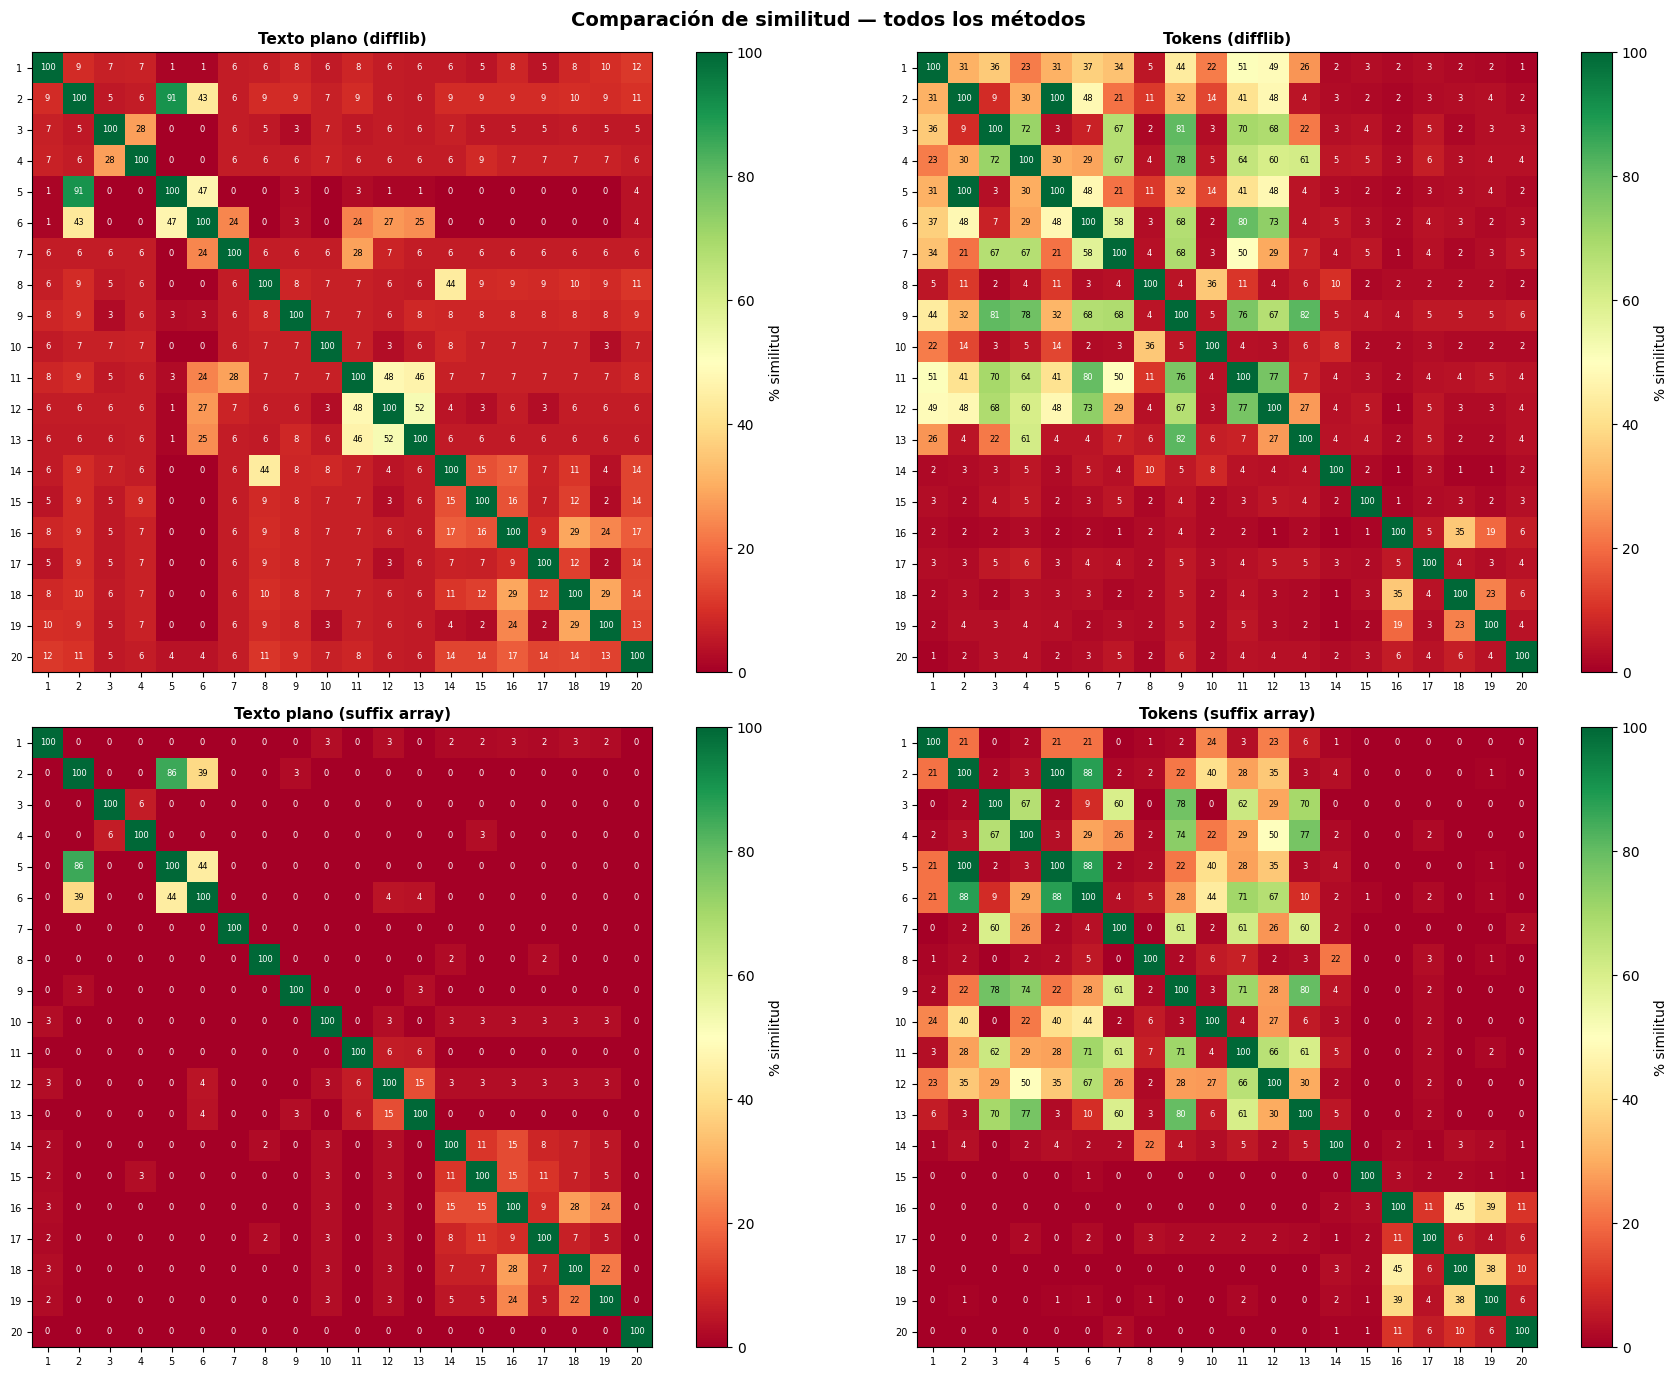

In [23]:
n = len(files)

m_plain_difflib  = np.zeros((n, n))
m_tokens_difflib = np.zeros((n, n))
m_plain_suffix   = np.zeros((n, n))
m_tokens_suffix  = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        if i < j:
            fa, fb = files[i], files[j]
            p1, _ = compare_plain_text(codes[fa], codes[fb])
            p2, _ = compare_tokens(tokens[fa], tokens[fb])
            p3, _ = compare_suffix_array_plain(codes[fa], codes[fb])
            p4, _ = compare_suffix_array_tokens(tokens[fa], tokens[fb])

            m_plain_difflib[i][j]  = m_plain_difflib[j][i]  = p1
            m_tokens_difflib[i][j] = m_tokens_difflib[j][i] = p2
            m_plain_suffix[i][j]   = m_plain_suffix[j][i]   = p3
            m_tokens_suffix[i][j]  = m_tokens_suffix[j][i]  = p4
        elif i == j:
            fa = files[i]
            p1, _ = compare_plain_text(codes[fa], codes[fa])
            p2, _ = compare_tokens(tokens[fa], tokens[fa])
            p3, _ = compare_suffix_array_plain(codes[fa], codes[fa])
            p4, _ = compare_suffix_array_tokens(tokens[fa], tokens[fa])

            m_plain_difflib[i][j]  = p1
            m_tokens_difflib[i][j] = p2
            m_plain_suffix[i][j]   = p3
            m_tokens_suffix[i][j]  = p4

labels   = [f.replace('.py', '') for f in files]
matrices = [m_plain_difflib, m_tokens_difflib, m_plain_suffix, m_tokens_suffix]
titles   = ['Texto plano (difflib)', 'Tokens (difflib)', 
            'Texto plano (suffix array)', 'Tokens (suffix array)']

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

for ax, matrix, title in zip(axes.flat, matrices, titles):
    im = ax.imshow(matrix, cmap='RdYlGn', vmin=0, vmax=100)
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(labels, fontsize=7)
    ax.set_yticklabels(labels, fontsize=7)
    ax.set_title(title, fontsize=11, fontweight='bold')
    plt.colorbar(im, ax=ax, label='% similitud')

    for i in range(n):
        for j in range(n):
            ax.text(j, i, f"{matrix[i][j]:.0f}",
                    ha='center', va='center', fontsize=6,
                    color='black' if 20 < matrix[i][j] < 80 else 'white')

plt.suptitle('Comparación de similitud — todos los métodos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('similarity_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

# Conclusión

Como se puede observar en el mapa de calor, lo métodos más eficientes fueron definitivamente los que utilizaron un texto preprocesdo con el uso de tokens para identificar clones, debido a que el texto plano al comparar linea por linea, una identación, un cambio en el formato o nombres de variables afectan gravemente. Aunque en varios de los casos los resultdos no suelen ser tan consistentes entre métodos, coinciden en las mismas zonas de clones. Aunque los porcentajes de similitud rara vez fueron altos aunque los clones fueran visualmente una copia casi exacta.


Texto plano con difflib: Solo detecta bien cuando el código es identico en formato.
Gracias a SequenceMatcher que no es tan estricto como diff de Unix, utiliza el algoritmo de Ratcliff que encuentra subsecuencias comunes mas largas y es tolerante a ciertos reordenamientos. Pero el cambio de variables hace que detecte como diferentes las líneas.

Tokens con difflib: De los 4 probados fue el más sensible y capaz de detectar aún con formato estructural. Al cambiar todos los identificadores a un solo tipo de valor, permite que las coincidencias aumenten aún con cambios de variables, y elimina toda diferencia de formato. 

Texto plano con suffix array: Solo fue capaz de detectar bloques literalmente idénticos.
Dado que se opera sobre las de texto literal y que exige al menos un par de lineas contiguas idénticas, solo lineas que son 100% idénticas son detectadas.

Tokens con sufixx array: Fue consistente y obtuvo resultados muy parecidos a los tokens con difflib.
En lugar de buscar subsecuencias comunes más largas que permite saltos como difflib, busca subcadenas contiguas de al menos unos 3 tokens. Cuando los programas tienen intercaladas las instruccione, difflib es capaz de conectarlas con saltos pero suffix array no.